# Download AIWP Reforecasts

[Link](https://registry.opendata.aws/aiwp/)

In [2]:
import re
import s3fs
import glob
import fsspec
import cartopy

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm
from utils import DATA_ROOT
from dask.distributed import Client, LocalCluster

## Download

In [2]:
fs = fsspec.filesystem('s3', anon=True)

all_files = fs.find('noaa-oar-mlwp-data/FOUR_v200_GFS/')  # For FourCastNet v2

pattern = re.compile(r'.*GFS_(\d{8})12_.*\.nc$')

files_to_download = [f for f in all_files if pattern.search(f)]

# data_dir = Path(DATA_ROOT) / 'input/AIWP/FOUR/PJM'
data_dir = Path(DATA_ROOT) / 'input/AIWP/FOUR/WestUS'
# data_dir = Path(DATA_ROOT) / 'input/AIWP/FOUR/GA'

# Spatial extent
# from utils.download import pjm_extent as my_extent
from utils.download import west_us_extent as my_extent
# from utils.download import ga_extent as my_extent

# Variables
# variables_to_download = ['t2', 'tcwv', 'u10', 'v10', 'r']
variables_to_download = 'all'

In [ ]:
%%time

# Connect to AWS
fs = s3fs.S3FileSystem(anon=True)

# Iterate through files
for f in tqdm(files_to_download, leave=False):
    outfile = Path(data_dir) / f.split('/')[-1]

    if not outfile.exists():
        with fs.open(f) as fobj:
            ds = xr.open_dataset(
                filename_or_obj=fobj, 
                engine='h5netcdf',
            )
            
            ds = ds.isel(
                longitude=(my_extent['xmin'] + 360 <= ds.longitude) & (ds.longitude <= my_extent['xmax'] + 360),
                latitude=(my_extent['ymin'] <= ds.latitude) & (ds.latitude <= my_extent['ymax']),
            )

            if variables_to_download != 'all':
                ds = ds[variables_to_download]
                
            ds.to_netcdf(path=outfile)

  0%|          | 0/1660 [00:00<?, ?it/s]

## Checking

In [5]:
ds = xr.open_dataset(
    Path(DATA_ROOT) /
    'input/AIWP/FOUR/PJM/FOUR_v200_GFS_2020093012_f000_f240_06.nc'
)

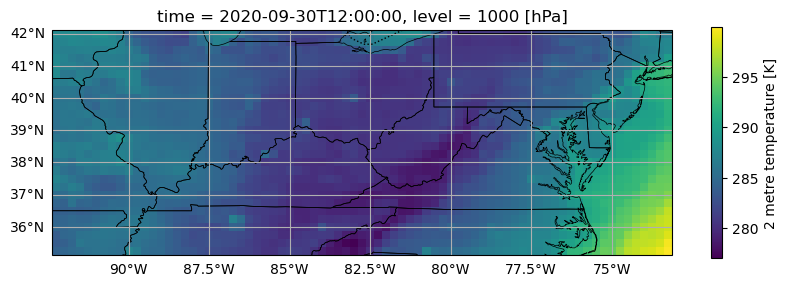

In [11]:
fig, ax = plt.subplots(
    figsize=(10, 3),
    subplot_kw={'projection': cartopy.crs.PlateCarree()}
)
ds.t2.isel(time=0).plot(ax=ax)
ax.add_feature(cartopy.feature.STATES, linewidth=0.5)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
plt.show()

## Combine Data

In [ ]:
cluster = LocalCluster(
    n_workers=8,
    threads_per_worker=1,
    memory_limit='3G',
    dashboard_address=':41228',
)

client = Client(cluster)

In [4]:
files = glob.glob(Path(DATA_ROOT) / 'input/AIWP/FOUR/PJM/*.nc')
files.sort()

In [5]:
def add_init_time(ds):
    match = re.search(r'(\d{10})', ds.encoding['source'])
    
    if not match:
        raise ValueError(f"No valid init_time found in filename: {filename}")
        
    init_str = match.group(1)
    init_datetime = pd.to_datetime(init_str, format="%Y%m%d%H")

    ds = ds.rename({'time': 'lead_time'})
    ds = ds.expand_dims({'init_time': [init_datetime]})
    ds = ds.drop_vars('level')
    ds['lead_time'] = [int(i) for i in (ds['lead_time'] - ds['lead_time'][0]).dt.total_seconds().to_numpy() / 3600]
    
    return ds

In [6]:
ds = xr.open_mfdataset(
    files, preprocess=add_init_time,
    concat_dim='init_time', combine='nested',
    parallel=True,
)

In [10]:
_ = ds.to_zarr(
    Path(DATA_ROOT) /
    'derived/AIWP/FOUR/FOUR_v200_GFS_PJM_2020093012_2025041912.zarr',
    zarr_format=2
)

## Checking 

In [2]:
ds = xr.open_zarr(
    Path(DATA_ROOT) /
    'derived/AIWP/FOUR/FOUR_v200_GFS_PJM_2020093012_2025041912.zarr'
)

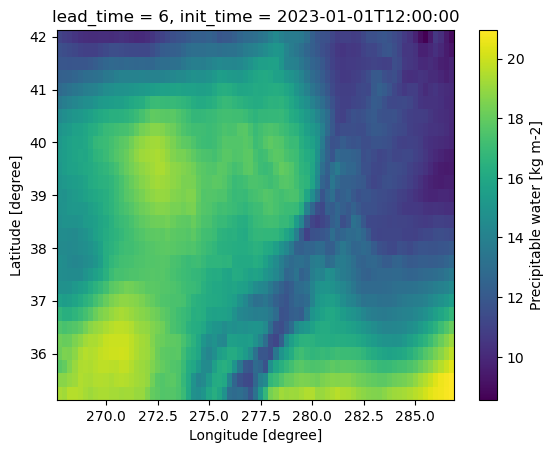

In [11]:
ds.tcwv.sel(init_time='2023-01-01', lead_time=6).plot()